# 重回帰分析：テスト点数を生活習慣から説明する
この分析では、テストの点数を目的変数とし、勉強時間・睡眠時間・出席率・前回の点数から説明する。

## Multiple regression analysis: Explaining test scores from lifestyle habits
In this analysis, test scores are used as the dependent variable, and the results are explained using study time, sleep time, attendance rate, and previous test scores.

In [1]:
## データ読み込み
## Data Loading
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"E:\Analytics\Multivariate-Analytics")
df = pd.read_csv(BASE_DIR / "01_multiple_regression\data\student_scores.csv")

df.head()

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\toshi\AppData\Local\Temp\ipykernel_18908\586329296.py:7: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv(BASE_DIR / "01_multiple_regression\data\student_scores.csv")


,student_id,study_hours,sleep_hours,attendance_rate,previous_score,score
0,A001,2.5,7.0,85,60,65
1,A002,3.0,6.5,90,70,72
2,A003,1.5,8.0,75,55,58
3,A004,4.0,6.0,95,80,85
4,A005,2.0,7.5,80,65,68


In [2]:
## 変数設定
## Variable Setting
X = df[["study_hours", "sleep_hours", "attendance_rate", "previous_score"]]
y = df["score"]

In [3]:
## モデル作成
## Model Creation
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [4]:
## 回帰係数を見る
## View Regression Coefficients
import pandas as pd

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

coef_df

,feature,coefficient
0,study_hours,5.078154
1,sleep_hours,9.498079
2,attendance_rate,0.625192
3,previous_score,0.751727


In [5]:
## 精度確認
## Accuracy Check
from sklearn.metrics import r2_score

y_pred = model.predict(X)

print("R2:", r2_score(y, y_pred))

R2: 0.9942826459553821


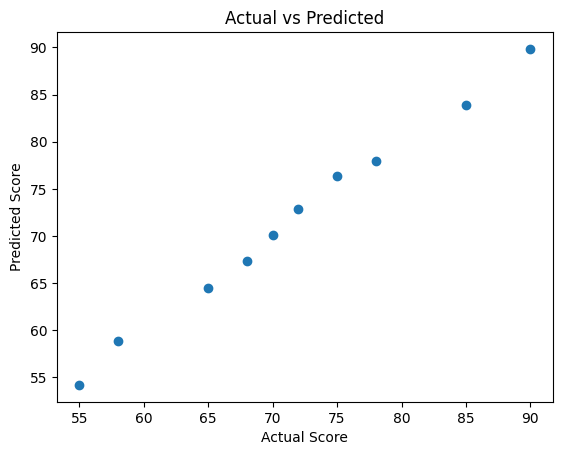

In [6]:
## 実測 vs 予測
## Actual vs Predicted
import matplotlib.pyplot as plt

plt.scatter(y, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()